# PythonとCasADiで学ぶLie群上の最適化

ロボットやドローンの**姿勢（回転）を変数とする最適化問題**を、Python と [CasADi](https://web.casadi.org/) で解けるようになることを目指して、**手を動かしながら**学ぶノートブックです。

回転行列は、足し算で更新すると回転行列でなくなってしまううえ、$R^\top R = I$ という制約も持つため、そのままでは最適化しにくい量です。そこで **Lie群・Lie代数**の考え方を使い、「曲がった空間の上の問題」を「ふつうのベクトル空間での、制約のない問題」に書き換えて解きます。

まず Lie群の基本操作（指数写像・対数写像）を CasADi で実装して性質を数値で確かめ、自動微分で「Lie群上の微分」（ヤコビ行列）を求め、最後にそれらを組み合わせて最適化問題を解きます。

**このノートブックで学ぶこと**

1. Lie群とLie代数の考え方（SO(2) を円周として眺める）
2. SO(3)（3次元の回転）の指数写像・対数写像を CasADi で実装する
3. Lie括弧と、回転の順序を入れ替えると結果が変わることの意味
4. CasADi の自動微分で「Lie群上の微分」（ヤコビ行列）を求める
5. 姿勢の数値積分：Lie群の構造を使うと何が嬉しいのか
6. SE(2)・SE(3)（位置と姿勢をまとめた剛体運動）
7. **Lie群上の最適化**：回転の推定（Gauss–Newton法）と SE(2) 上の軌道最適化（`Opti`）

**対象読者**：線形代数と微分の基礎（大学初年次程度）と Python の基本的な知識があれば読めます。CasADi は初めてでも構いません。

**動作確認環境**：Python 3.11 / CasADi 3.7 / NumPy 2.2 / Matplotlib 3.10

## 0. Lie群とは何か

### 群

「掛け算」ができる集合 $G$ が次の4つを満たすとき、$G$ を**群**といいます。

- 2つの元 $g_1, g_2$ を掛けても $G$ の中に収まる（$g_1 g_2 \in G$）
- 何もしない元 $I$（**単位元**）がある（$gI = Ig = g$）
- どの元 $g$ にも**逆元** $g^{-1}$ がある（$g g^{-1} = g^{-1} g = I$）
- 結合法則 $(g_1 g_2) g_3 = g_1 (g_2 g_3)$ が成り立つ

### Lie群

群であり、同時に**なめらかな曲面（多様体）**でもあるものを **Lie群**といいます（掛け算や逆元をとる操作もなめらかであるものとします）。代表例は回転の集まりです。

$$
\mathrm{SO}(3) = \{ R \in \mathbb{R}^{3\times 3} \mid R^\top R = I,\ \det R = 1 \}
$$

$R$ は $3\times 3 = 9$ 個の数で書かれますが、$R^\top R = I$ が6本の条件を課すため、実際に動ける自由度は $9 - 6 = 3$ です。つまり SO(3) は、9次元空間に埋め込まれた**3次元の曲がった面**です。

ここが重要な点で、**回転どうしは足し算できません**。$R_1 + R_2$ は一般に回転行列ではないからです。回転を合成するには「掛け算」を使います。

### Lie代数

曲面の上で微分や足し算をしたいときは、単位元 $I$ における**接空間**（曲面にぴったり接する平らな空間）を使います。これを **Lie代数** $\mathfrak{g}$ といいます。Lie代数はふつうのベクトル空間なので、足し算も微分も自由にできます。

Lie群とLie代数は、次の2つの写像で行き来できます。

- **指数写像** $\exp: \mathfrak{g} \to G$ ：平らな空間の点を、曲面に「巻きつける」
- **対数写像** $\log: G \to \mathfrak{g}$ ：曲面上の点を、平らな空間に「ほどく」

このノートブックで扱うLie群は次の4つです。

| Lie群 | 意味 | 次元 | Lie代数の元（ベクトル表現） |
| --- | --- | --- | --- |
| SO(2) | 平面の回転 | 1 | 回転角 $\theta$ |
| SO(3) | 空間の回転 | 3 | 回転ベクトル $\phi \in \mathbb{R}^3$ |
| SE(2) | 平面の剛体運動（位置と向き） | 3 | $(\rho, \omega)$：並進と回転の速度 |
| SE(3) | 空間の剛体運動（位置と姿勢） | 6 | $(\rho, \phi)$：並進と回転の速度（ツイスト） |

ロボット・ドローン・自動運転では、姿勢や「位置と向き」がまさにこれらのLie群の元です。

## 準備：ライブラリと CasADi の最小限の使い方

まず、必要なライブラリを読み込みます。

In [1]:
# Google Colab など casadi が入っていない環境では、次の行の # を外して実行してください
# !pip install casadi

import numpy as np
import casadi as ca
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

print("CasADi", ca.__version__)

CasADi 3.7.0


CasADi は、**記号式**を組み立て、**自動微分**で厳密な微分を計算できるライブラリです。このノートブックで使う機能は主に次の3つです。

- `ca.SX.sym` … 記号変数（スカラー・ベクトル・行列）を作る
- `ca.Function` … 記号式を、数値を入れて評価できる関数にする
- `ca.jacobian` … 記号式のヤコビ行列を自動微分で求める

（`.full()` は CasADi の数値型 `DM` を NumPy 配列に変換します。）

In [2]:
x = ca.SX.sym("x", 2)                                    # 記号変数（2次元ベクトル）
f = ca.vertcat(x[0] ** 2 + x[1], ca.sin(x[0]) * x[1])    # 記号式
F = ca.Function("F", [x], [f])                           # 数値を入れて評価できる関数
J = ca.Function("J", [x], [ca.jacobian(f, x)])           # ヤコビ行列（自動微分）

print("F(1, 2) =", F([1.0, 2.0]).full().ravel())
print("J(1, 2) =\n", J([1.0, 2.0]).full())

F(1, 2) = [3.     1.6829]
J(1, 2) =
 [[2.     1.    ]
 [1.0806 0.8415]]


## 1. SO(2)：円周としてのLie群

もっとも簡単なLie群は、平面の回転 $\mathrm{SO}(2)$ です。

$$
R(\theta) = \begin{pmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{pmatrix}
$$

1つの数 $\theta$ で決まるので、1次元のLie群です。$R(\theta)$ を点 $R(\theta)\,e_1 = (\cos\theta, \sin\theta)^\top$ と同一視すると、SO(2) は**単位円**そのものです。

まず、群としての性質を数値で確かめましょう。

In [3]:
th = ca.SX.sym("th")
R2_expr = ca.vertcat(ca.horzcat(ca.cos(th), -ca.sin(th)),
                     ca.horzcat(ca.sin(th),  ca.cos(th)))
R2 = ca.Function("R2", [th], [R2_expr])           # θ から R(θ) を作る関数

a, b = 0.7, 1.1
Ra, Rb = R2(a).full(), R2(b).full()

print("閉じている : R(a) R(b) = R(a+b)          ->", np.allclose(Ra @ Rb, R2(a + b).full()))
print("単位元     : R(0) = I                    ->", np.allclose(R2(0.0).full(), np.eye(2)))
print("逆元       : R(a)^-1 = R(a)^T = R(-a)    ->", np.allclose(Ra.T, R2(-a).full()) and np.allclose(Ra @ Ra.T, np.eye(2)))
print("det R = 1  :                             ->", np.isclose(np.linalg.det(Ra), 1.0))
print("可換       : R(a) R(b) = R(b) R(a)       ->", np.allclose(Ra @ Rb, Rb @ Ra))

閉じている : R(a) R(b) = R(a+b)          -> True
単位元     : R(0) = I                    -> True
逆元       : R(a)^-1 = R(a)^T = R(-a)    -> True
det R = 1  :                             -> True
可換       : R(a) R(b) = R(b) R(a)       -> True


### Lie代数：単位元での接ベクトル

単位元（$\theta=0$）での $R(\theta)$ の微分が、Lie代数 $\mathfrak{so}(2)$ の基底 $G$ です。CasADi の自動微分で求めてみましょう。

In [4]:
dR = ca.reshape(ca.jacobian(ca.vec(R2_expr), th), 2, 2)    # dR/dθ を自動微分で求める
G = ca.Function("G", [th], [dR])(0.0).full() + 0.0         # θ = 0 で評価（+ 0.0 は -0. の表示を避けるため）

print("G = dR/dθ |θ=0 =\n", G)

G = dR/dθ |θ=0 =
 [[ 0. -1.]
 [ 1.  0.]]


$G$ は「90°回転」の行列で、「単位元から少しだけ回す」向きを表しています。Lie代数の元は、この $G$ のスカラー倍 $\theta G$ です。

### 指数写像：$\exp(\theta G) = R(\theta)$

Lie代数の元 $\theta G$ に**行列の指数関数**を適用すると、ちょうど回転行列 $R(\theta)$ になります。

$$
\exp(\theta G) = I + \theta G + \frac{(\theta G)^2}{2!} + \cdots = \cos\theta \, I + \sin\theta \, G = R(\theta)
$$

（$G^2 = -I$ なので、級数は $\cos$ と $\sin$ の級数に一致します。）これも数値で確かめます。行列の指数関数は、定義どおり級数で計算する関数を用意します。

In [5]:
def expm_series(A, n_terms=30):
    """行列指数関数 exp(A) = I + A + A^2/2! + ... を級数で計算する（検算用）"""
    E, term = np.eye(A.shape[0]), np.eye(A.shape[0])
    for k in range(1, n_terms):
        term = term @ A / k
        E = E + term
    return E

theta = 0.9
print("exp(θG) = R(θ) ->", np.allclose(expm_series(theta * G), R2(theta).full()))

exp(θG) = R(θ) -> True


下の図は、指数写像のイメージです。単位元 $(1, 0)$ での**接線**が Lie代数（平らな空間）で、$\exp$ はこの直線を**円に巻きつけます**。接線上の点 $\theta$（丸）は、円周上を長さ $\theta$ だけ進んだ点（四角）に写ります。逆に $\log$ は円周を直線にほどく操作です。

なお、$\theta$ と $\theta + 2\pi$ は同じ回転になるので、$\exp$ は「多対1」の写像です。そのため $\log$ は $(-\pi, \pi]$ の範囲の値（主値）を返すことにします。

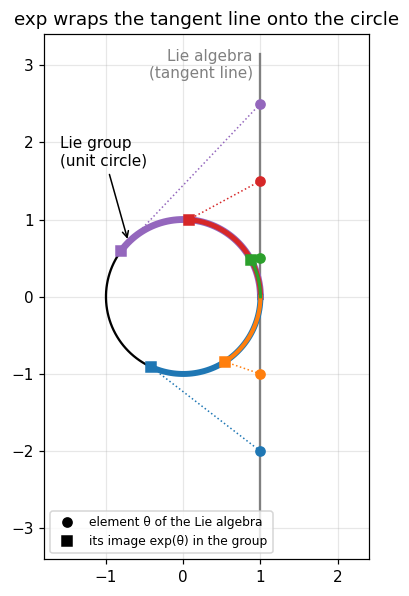

In [6]:
fig, ax = plt.subplots(figsize=(5, 6.2))
t = np.linspace(0, 2 * np.pi, 400)
ax.plot(np.cos(t), np.sin(t), "k", lw=1.5)                         # Lie群 SO(2) = 単位円
ax.plot([1, 1], [-np.pi, np.pi], color="gray", lw=1.5)             # 単位元 (1, 0) での接線 = Lie代数

for th_i, c in zip([2.5, -2.0, 1.5, -1.0, 0.5], ["C4", "C0", "C3", "C1", "C2"]):   # 長い弧から順に描く
    arc = np.linspace(0, th_i, 60)
    ax.plot(np.cos(arc), np.sin(arc), color=c, lw=1.5 + 1.2 * abs(th_i))   # exp：長さ θ の弧として巻きつく
    ax.plot([1, np.cos(th_i)], [th_i, np.sin(th_i)], ":", color=c, lw=1)
    ax.plot(1, th_i, "o", color=c)                                 # Lie代数の元 θ
    ax.plot(np.cos(th_i), np.sin(th_i), "s", color=c)              # その像 exp(θ)

ax.plot([], [], "ko", label="element θ of the Lie algebra")
ax.plot([], [], "ks", label="its image exp(θ) in the group")
ax.annotate("Lie group\n(unit circle)", xy=(-0.71, 0.71), xytext=(-1.6, 1.7), arrowprops=dict(arrowstyle="->"))
ax.text(0.9, 3.0, "Lie algebra\n(tangent line)", color="gray", ha="right", va="center")
ax.set(xlim=(-1.8, 2.4), ylim=(-3.4, 3.4), aspect="equal",
       title="exp wraps the tangent line onto the circle")
ax.legend(loc="lower left", fontsize=8)
plt.show()

## 2. SO(3)：3次元の回転

### hat 演算子とLie代数

3次元ベクトル $\phi = (\phi_1, \phi_2, \phi_3)^\top$ を**歪対称行列**（$A^\top = -A$ を満たす行列）に対応させる操作を **hat** と呼びます。

$$
\phi^\wedge = \begin{pmatrix} 0 & -\phi_3 & \phi_2 \\ \phi_3 & 0 & -\phi_1 \\ -\phi_2 & \phi_1 & 0 \end{pmatrix}
$$

$\phi^\wedge v = \phi \times v$（外積）となるのが特徴です。歪対称行列の全体が SO(3) のLie代数 $\mathfrak{so}(3)$ で、hat の逆の操作を **vee** $(\cdot)^\vee$ と書きます。つまり、**Lie代数の元は3次元ベクトル $\phi$ で表せます**（$\phi$ の向きが回転軸、大きさ $\lVert\phi\rVert$ が回転角です）。

In [7]:
def hat(w):
    """R^3 -> so(3)：3次元ベクトルを歪対称行列にする（hat(w) @ v = w × v）"""
    return ca.vertcat(ca.horzcat(0, -w[2], w[1]),
                      ca.horzcat(w[2], 0, -w[0]),
                      ca.horzcat(-w[1], w[0], 0))

def vee(W):
    """so(3) -> R^3：hat の逆の操作"""
    return ca.vertcat(W[2, 1], W[0, 2], W[1, 0])

w, v = np.array([1.0, 2.0, 3.0]), np.array([4.0, 5.0, 6.0])
print("hat(w) v = w × v :", np.allclose(hat(w).full() @ v, np.cross(w, v)))
print("vee(hat(w)) = w  :", np.allclose(vee(hat(w)).full().ravel(), w))

hat(w) v = w × v : True
vee(hat(w)) = w  : True


### 指数写像（Rodrigues の公式）

ベクトル $\phi$ を受け取って回転行列を返す写像を $\mathrm{Exp}(\phi) = \exp(\phi^\wedge)$ と書きます。SO(3) では、行列の指数関数が次の閉じた形で書けます（**Rodrigues の公式**）。

$$
\mathrm{Exp}(\phi) = I + \frac{\sin\theta}{\theta}\,\phi^\wedge + \frac{1-\cos\theta}{\theta^2}\,(\phi^\wedge)^2, \qquad \theta = \lVert\phi\rVert
$$

これは「軸 $\phi/\theta$ のまわりに角度 $\theta$ だけ回す」回転行列です。

> **実装上のポイント（0割りの回避）**
>
> $\sin\theta/\theta$ や $(1-\cos\theta)/\theta^2$ は、$\theta \to 0$ で $0/0$ になってしまいます。そこで $\theta^2$ が十分小さいときは**テイラー展開**を使います。
>
> また、CasADi の `ca.if_else` は**両方の枝を計算**するため、使わない側の枝が 0 除算になると、自動微分で `NaN` が混入します。下のコードで分母にダミー値（`t2s`）を入れているのは、これを防ぐためです。

In [8]:
def trig_coeffs(t2):
    """A = sinθ/θ, B = (1-cosθ)/θ², C = (θ-sinθ)/θ³ を θ² から計算する（θ → 0 でも安全）"""
    small = t2 < 1e-6
    t2s = ca.if_else(small, 1.0, t2)             # 使わない側の枝でも 0 除算にならないようにするダミー値
    t = ca.sqrt(t2s)
    A = ca.if_else(small, 1 - t2 / 6 + t2**2 / 120,     ca.sin(t) / t)
    B = ca.if_else(small, 1 / 2 - t2 / 24 + t2**2 / 720, (1 - ca.cos(t)) / t2s)
    C = ca.if_else(small, 1 / 6 - t2 / 120 + t2**2 / 5040, (t - ca.sin(t)) / (t * t2s))
    return A, B, C

def exp_so3(phi):
    """Exp: R^3 -> SO(3)（Rodrigues の公式）"""
    A, B, _ = trig_coeffs(ca.dot(phi, phi))
    W = hat(phi)
    return ca.SX.eye(3) + A * W + B * (W @ W)

phi = ca.SX.sym("phi", 3)
Exp_SO3 = ca.Function("Exp_SO3", [phi], [exp_so3(phi)])

### 対数写像

逆に、回転行列 $R$ から回転ベクトルを取り出す写像が $\mathrm{Log}$ です。

$$
\theta = \arccos\frac{\mathrm{tr}(R) - 1}{2}, \qquad \mathrm{Log}(R) = \frac{\theta}{2\sin\theta}\,(R - R^\top)^\vee
$$

実装では、$\sin\theta = \lVert(R - R^\top)^\vee\rVert/2$ と $\cos\theta = (\mathrm{tr}(R) - 1)/2$ から $\theta = \mathrm{atan2}(\sin\theta, \cos\theta)$ と求めると、$\theta$ が $\pi$ に近くても精度が落ちません。

> **注意**：$\theta = \pi$（180°回転）ちょうどでは、$\phi$ と $-\phi$ が同じ回転になるため、$\mathrm{Log}$ は一意に決まりません（特異点）。このノートブックでは $\lVert\phi\rVert < \pi$ の範囲を扱います。

In [9]:
def log_so3(R):
    """Log: SO(3) -> R^3（|φ| < π）"""
    v = vee(R - R.T) / 2                           # = sinθ · 回転軸
    c = (ca.trace(R) - 1) / 2                      # = cosθ
    s2 = ca.dot(v, v)                              # = sin²θ
    near_id = ca.logic_and(s2 < 1e-12, c > 0)      # 単位行列の近く（θ ≈ 0）
    s2s = ca.if_else(near_id, 1.0, s2)             # 0 除算を避けるダミー値
    s = ca.sqrt(s2s)
    k = ca.if_else(near_id, 1 + s2 / 6, ca.atan2(s, c) / s)   # k = θ / sinθ
    return k * v

R = ca.SX.sym("R", 3, 3)
Log_SO3 = ca.Function("Log_SO3", [R], [log_so3(R)])

実装した $\mathrm{Exp}$ と $\mathrm{Log}$ が正しいか、いくつかの性質を使って検算します。

In [10]:
phi0 = np.array([0.3, -0.5, 0.8])
R0 = Exp_SO3(phi0).full()

print("R^T R = I         :", np.allclose(R0.T @ R0, np.eye(3)))
print("det R = 1         :", np.isclose(np.linalg.det(R0), 1.0))
print("expm（級数）と一致 :", np.allclose(R0, expm_series(hat(phi0).full())))
print("回転軸が不変       :", np.allclose(R0 @ phi0, phi0))
print("回転角 = |φ|       :", np.isclose(np.arccos((np.trace(R0) - 1) / 2), np.linalg.norm(phi0)))
print("Log(Exp(φ)) = φ   :", np.allclose(Log_SO3(R0).full().ravel(), phi0))

R^T R = I         : True
det R = 1         : True
expm（級数）と一致 : True
回転軸が不変       : True
回転角 = |φ|       : True
Log(Exp(φ)) = φ   : True


$\mathrm{Exp}(\phi)$ が何をしているか、図で見てみましょう。灰色の矢印が元の座標系 $(x, y, z)$、色つきの矢印が $\mathrm{Exp}(\phi)$ で回した座標系 $(x', y', z')$（赤・緑・青の順）、黒い破線が回転軸 $\phi/\lVert\phi\rVert$ です。

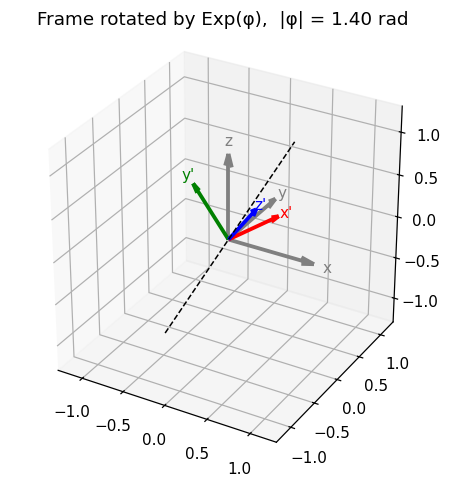

In [11]:
def draw_frame(ax, R, p=(0.0, 0.0, 0.0), scale=1.0, color=None, names=None, zorder=2):
    """3次元の座標系を矢印で描く。R の各列が座標軸の向き（color を省略すると x: 赤, y: 緑, z: 青）"""
    for i in range(3):
        c = color or "rgb"[i]
        ax.quiver(*p, *(scale * R[:, i]), color=c, lw=2.5, arrow_length_ratio=0.15, zorder=zorder)
        if names:
            ax.text(*(np.asarray(p) + 1.15 * scale * R[:, i]), names[i], color=c, ha="center", va="center")

def setup_3d(ax, lim=1.3, center=(0.0, 0.0, 0.0), title=""):
    cx, cy, cz = center
    ax.set(xlim=(cx - lim, cx + lim), ylim=(cy - lim, cy + lim), zlim=(cz - lim, cz + lim), title=title)
    ax.set_box_aspect((1, 1, 1))

phi_vis = np.array([0.6, 0.4, 1.2])
axis = phi_vis / np.linalg.norm(phi_vis)

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(projection="3d", computed_zorder=False)     # zorder を指定して、元の座標系を常に後ろに描く
draw_frame(ax, np.eye(3), color="gray", names=("x", "y", "z"), zorder=1)         # 元の座標系
draw_frame(ax, Exp_SO3(phi_vis).full(), scale=0.7, names=("x'", "y'", "z'"))     # Exp(φ) で回した座標系
ax.plot(*np.c_[-1.3 * axis, 1.3 * axis], "k--", lw=1)                           # 回転軸
setup_3d(ax, title=f"Frame rotated by Exp(φ),  |φ| = {np.linalg.norm(phi_vis):.2f} rad")
plt.show()

## 3. Lie括弧と非可換性

SO(2) では回転の順序を入れ替えても結果は同じでしたが、SO(3) では**順序によって結果が変わります**。x軸まわりに90°回す回転 $R_x$ と、y軸まわりに90°回す回転 $R_y$ を、掛ける順序を変えて比べてみましょう（灰色の矢印が元の座標系 $x, y, z$、色つきの矢印が回転後の座標系 $x', y', z'$ です）。

Rx Ry = Ry Rx ? False


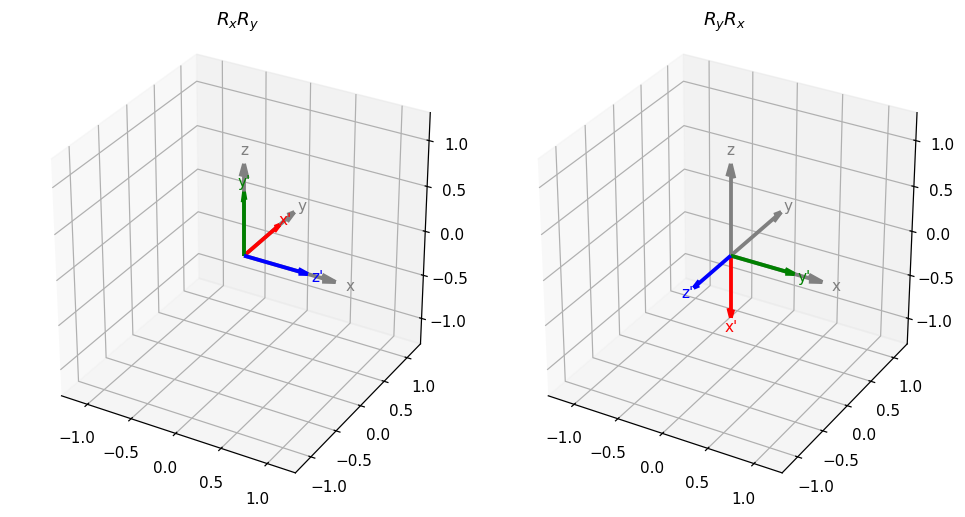

In [12]:
Rx = Exp_SO3([np.pi / 2, 0, 0]).full()     # x軸まわりに 90°
Ry = Exp_SO3([0, np.pi / 2, 0]).full()     # y軸まわりに 90°
print("Rx Ry = Ry Rx ?", np.allclose(Rx @ Ry, Ry @ Rx))

fig = plt.figure(figsize=(9, 4.5))
for i, (R_, title) in enumerate([(Rx @ Ry, r"$R_x R_y$"), (Ry @ Rx, r"$R_y R_x$")]):
    ax = fig.add_subplot(1, 2, i + 1, projection="3d", computed_zorder=False)
    draw_frame(ax, np.eye(3), color="gray", names=("x", "y", "z"), zorder=1)      # 元の座標系
    draw_frame(ax, R_, scale=0.7, names=("x'", "y'", "z'"))                      # 回転後の座標系
    setup_3d(ax, title=title)
plt.tight_layout()
plt.show()

左では $x'$ が元の $y$ 軸の向き、右では $x'$ が元の $-z$ 軸の向きを向いており、結果が異なることが分かります。

### Lie括弧

この「掛ける順序によるずれ」を、Lie代数の側で測るのが **Lie括弧**（交換子）です。

$$
[a^\wedge, b^\wedge] = a^\wedge b^\wedge - b^\wedge a^\wedge = (a \times b)^\wedge
$$

右辺のとおり、$\mathfrak{so}(3)$ のLie括弧は**外積**に対応します。2つの元が可換なら $0$ ですが、一般には $a \times b \neq 0$ です。

In [13]:
a = np.array([0.3, -0.2, 0.5])
b = np.array([-0.1, 0.4, 0.2])
Ah, Bh = hat(a).full(), hat(b).full()

print("[a^, b^] = (a × b)^ :", np.allclose(Ah @ Bh - Bh @ Ah, hat(np.cross(a, b)).full()))

[a^, b^] = (a × b)^ : True


### Lie括弧は「群の掛け算」のずれを表す

$\mathrm{Exp}(a)\,\mathrm{Exp}(b)$ を再び1つの $\mathrm{Exp}$ にまとめると、Lie代数側では何が起きているのでしょうか。その答えが **BCH（Baker–Campbell–Hausdorff）公式**です。

$$
\mathrm{Log}\bigl(\mathrm{Exp}(a)\,\mathrm{Exp}(b)\bigr) = a + b + \frac{1}{2}\,a \times b + \frac{1}{12}\Bigl( a \times (a \times b) + b \times (b \times a) \Bigr) + \cdots
$$

もし可換なら $a + b$ だけで済みますが、実際には Lie括弧（外積）による**補正項**が続きます。$a, b$ を $\varepsilon$ 倍して小さくしていったとき、各項まで取った近似の誤差が $\varepsilon$ の何乗で小さくなるかを調べます。

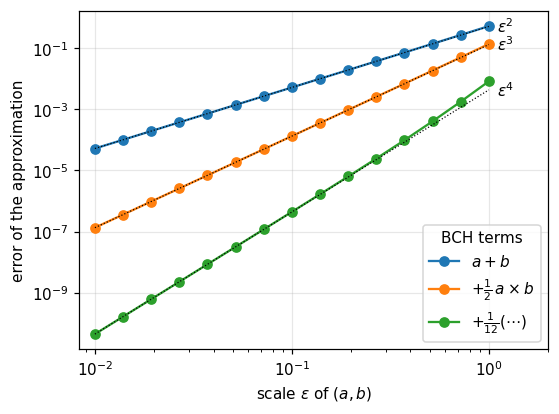

In [14]:
a0, b0 = np.array([1.0, 0.0, 0.5]), np.array([-0.3, 0.8, 0.4])
eps = np.logspace(-2, 0, 15)
errors = np.zeros((3, len(eps)))

for j, e in enumerate(eps):
    a, b = e * a0, e * b0
    c = Log_SO3(Exp_SO3(a).full() @ Exp_SO3(b).full()).full().ravel()      # Log(Exp(a) Exp(b))
    term1 = a + b
    term2 = term1 + np.cross(a, b) / 2
    term3 = term2 + (np.cross(a, np.cross(a, b)) + np.cross(b, np.cross(b, a))) / 12
    errors[:, j] = [np.linalg.norm(c - t) for t in (term1, term2, term3)]

fig, ax = plt.subplots(figsize=(5.5, 4))
labels = [r"$a+b$", r"$+\frac{1}{2}\,a\times b$", r"$+\frac{1}{12}(\cdots)$"]
for k in range(3):
    ax.loglog(eps, errors[k], "o-", label=labels[k])
    ref = errors[k, 0] * (eps / eps[0]) ** (k + 2)                              # 参考線（傾き 2, 3, 4）
    ax.loglog(eps, ref, "k:", lw=0.8)
    ax.text(eps[-1] * 1.1, ref[-1], rf"$\varepsilon^{k + 2}$", va="center")
ax.set(xlabel=r"scale $\varepsilon$ of $(a, b)$", ylabel="error of the approximation",
       xlim=(eps[0] / 1.2, eps[-1] * 2))
ax.legend(title="BCH terms", loc="lower right")
plt.show()

誤差の傾きは、$a + b$ だけだと 2、外積の項を足すと 3、さらに次の項を足すと 4 になります（黒の点線は傾き 2, 3, 4 の参考線です）。Lie括弧の項を足すたびに、近似の次数が1つ上がっていることが分かります。

つまり、**$\mathrm{Exp}(a)\,\mathrm{Exp}(b) \neq \mathrm{Exp}(a+b)$ のずれの正体が Lie括弧**です。SO(2) のように Lie括弧が 0 なら、$\mathrm{Exp}(a)\,\mathrm{Exp}(b) = \mathrm{Exp}(a+b)$ が成り立ちます。

## 4. 自動微分で「Lie群上の微分」を求める

### 摂動で微分する

回転 $R$ の関数 $f(R)$ を微分したいとします。$R$ は9成分ですが、動ける自由度は3なので、9成分で素朴に偏微分すると、$R$ が SO(3) から外れる方向の変化まで含んでしまいます。そこで、Lie代数の微小な元 $\delta \in \mathbb{R}^3$ に対する**摂動**で $R$ を動かし、$\delta$ について微分します。

$$
\frac{\partial f}{\partial \delta}\bigg|_{\delta = 0} \quad\text{ただし}\quad f = f\bigl(R\,\mathrm{Exp}(\delta)\bigr)
$$

（右から掛ける**右摂動**です。左から $\mathrm{Exp}(\delta)\,R$ と掛ける左摂動もあります。）

### 例1：点の回転 $R\,p$ の微分

手計算すると、$R\,\mathrm{Exp}(\delta)\,p \approx R\,(I + \delta^\wedge)\,p = R\,p - R\,p^\wedge \delta$ より、

$$
\frac{\partial\,\bigl(R\,\mathrm{Exp}(\delta)\,p\bigr)}{\partial \delta}\bigg|_{\delta = 0} = -R\,p^\wedge
$$

です。CasADi では、この手計算をしなくても同じ結果が得られます。

In [15]:
delta = ca.SX.sym("delta", 3)
R_s = ca.SX.sym("R_s", 3, 3)
p_s = ca.SX.sym("p_s", 3)

f = R_s @ Exp_SO3(delta) @ p_s                              # f(R Exp(δ)) = R Exp(δ) p
J_f = ca.Function("J_f", [R_s, p_s, delta], [ca.jacobian(f, delta)])

p0 = np.array([1.0, 2.0, 3.0])
J_ad = J_f(R0, p0, np.zeros(3)).full()                      # 自動微分（δ = 0 で評価）
J_hand = -R0 @ hat(p0).full()                               # 手計算の結果

print("自動微分:\n", J_ad)
print("手計算と一致:", np.allclose(J_ad, J_hand))

自動微分:
 [[ 1.6105  2.0823 -1.925 ]
 [-2.8666  2.2571 -0.5492]
 [ 1.4794  0.7548 -0.9964]]
手計算と一致: True


### 例2：$\mathrm{Exp}$ の微分（右ヤコビアン）

$\phi$ を少し動かしたとき、$\mathrm{Exp}(\phi)$ はどう変わるでしょうか。SO(2) のように可換なら $\mathrm{Exp}(\phi + \delta) = \mathrm{Exp}(\phi)\,\mathrm{Exp}(\delta)$ ですが、SO(3) ではそうならず、補正として**右ヤコビアン** $J_r(\phi)$ が現れます。

$$
\mathrm{Exp}(\phi + \delta) \approx \mathrm{Exp}(\phi)\,\mathrm{Exp}\bigl(J_r(\phi)\,\delta\bigr), \qquad
J_r(\phi) = I - \frac{1-\cos\theta}{\theta^2}\,\phi^\wedge + \frac{\theta - \sin\theta}{\theta^3}\,(\phi^\wedge)^2
$$

つまり、$J_r(\phi)$ は $\mathrm{Log}\bigl(\mathrm{Exp}(\phi)^{-1}\,\mathrm{Exp}(\phi + \delta)\bigr)$ の $\delta$ についての微分（$\delta = 0$）です。この右辺をそのまま CasADi に書いて自動微分し、公式と比べてみます。

In [16]:
phi_s = ca.SX.sym("phi_s", 3)

# 自動微分による J_r：Log(Exp(φ)^T Exp(φ+δ)) を δ で微分する
rel = Log_SO3(Exp_SO3(phi_s).T @ Exp_SO3(phi_s + delta))
Jr_ad = ca.Function("Jr_ad", [phi_s, delta], [ca.jacobian(rel, delta)])

# 公式による J_r
_, B, C = trig_coeffs(ca.dot(phi_s, phi_s))
W = hat(phi_s)
Jr_formula = ca.Function("Jr_formula", [phi_s], [ca.SX.eye(3) - B * W + C * (W @ W)])

print("自動微分:\n", Jr_ad(phi0, np.zeros(3)).full())
print("公式:\n", Jr_formula(phi0).full())
print("一致:", np.allclose(Jr_ad(phi0, np.zeros(3)).full(), Jr_formula(phi0).full()))

自動微分:
 [[ 0.8588  0.3446  0.2683]
 [-0.3922  0.8842  0.0747]
 [-0.1922 -0.2016  0.946 ]]
公式:
 [[ 0.8588  0.3446  0.2683]
 [-0.3922  0.8842  0.0747]
 [-0.1922 -0.2016  0.946 ]]
一致: True


自動微分の結果が公式と一致しました。最後に、$J_r$ による補正の効果を確かめます。

In [17]:
d = 1e-3 * np.array([0.5, -1.0, 0.7])
lhs = Exp_SO3(phi0 + d).full()
rhs_Jr = R0 @ Exp_SO3(Jr_formula(phi0).full() @ d).full()      # Exp(φ) Exp(J_r δ)
rhs_naive = R0 @ Exp_SO3(d).full()                             # Exp(φ) Exp(δ)（補正なし）

print("‖Exp(φ+δ) - Exp(φ) Exp(J_r δ)‖ =", np.linalg.norm(lhs - rhs_Jr))
print("‖Exp(φ+δ) - Exp(φ) Exp(δ)‖     =", np.linalg.norm(lhs - rhs_naive), " <- 補正なしだと誤差が桁違いに大きい")

‖Exp(φ+δ) - Exp(φ) Exp(J_r δ)‖ = 7.422480862965897e-08
‖Exp(φ+δ) - Exp(φ) Exp(δ)‖     = 0.00033784251592380594  <- 補正なしだと誤差が桁違いに大きい


> **CasADi を使う利点**：$\mathrm{Exp}$ や $\mathrm{Log}$ を何重にも合成した複雑な関数でも、`ca.jacobian` を呼ぶだけで正確なヤコビ行列が得られます。ヤコビアンの公式を導出する手間と間違いのリスクがなくなり、そのまま最適化（Newton法など）に使えます。

## 5. Lie群の構造を使った数値積分

剛体の姿勢 $R(t) \in \mathrm{SO}(3)$ が、ボディ座標系の角速度 $\omega$ で回転しているとき、運動方程式は

$$
\dot{R} = R\,\omega^\wedge
$$

です。この微分方程式を数値的に解く3つの方法を比べます。

1. **オイラー法**（$R$ の9成分をそのまま更新）：$R_{k+1} = R_k + \Delta t\,R_k\,\omega^\wedge$
2. **ルンゲ・クッタ法（RK4）**（$R$ の9成分をそのまま更新）
3. **Lie群積分**：$R_{k+1} = R_k\,\mathrm{Exp}(\Delta t\,\omega)$

3 は、「$\Delta t$ の間は角速度が一定」とみなし、その間の回転を指数写像で**ぴったり**計算する方法です。回転行列に回転行列を掛けているだけなので、**常に SO(3) の上にとどまります**。

一方、1・2 は行列の成分を足し算で更新するため、少しずつ SO(3) から外れていきます。たとえばオイラー法では

$$
(I + \Delta t\,\omega^\wedge)^\top (I + \Delta t\,\omega^\wedge) = I - \Delta t^2\,(\omega^\wedge)^2 \neq I
$$

となり、更新のたびに行列が「膨らんで」いきます。

In [18]:
dt, n_steps = 0.05, 400                         # 20 秒分
omega = np.array([0.8, 1.2, -0.6])              # 一定の角速度 [rad/s]（ボディ座標系）

R_k_s, w_s = ca.SX.sym("R_k_s", 3, 3), ca.SX.sym("w_s", 3)
rhs = lambda R: R @ hat(w_s)                    # dR/dt = R ω^

k1 = rhs(R_k_s)
k2 = rhs(R_k_s + dt / 2 * k1)
k3 = rhs(R_k_s + dt / 2 * k2)
k4 = rhs(R_k_s + dt * k3)

steps = {
    "Euler":              ca.Function("euler", [R_k_s, w_s], [R_k_s + dt * k1]),
    "RK4":                ca.Function("rk4",   [R_k_s, w_s], [R_k_s + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)]),
    "Lie: R Exp(ω dt)":   ca.Function("lie",   [R_k_s, w_s], [R_k_s @ Exp_SO3(dt * w_s)]),
}

t_grid = dt * np.arange(1, n_steps + 1)
orth_err, exact_err = {}, {}
for name, step in steps.items():
    R_k = np.eye(3)
    orth_err[name], exact_err[name] = [], []
    for k in range(n_steps):
        R_k = step(R_k, omega).full()
        orth_err[name].append(np.linalg.norm(R_k.T @ R_k - np.eye(3)))                   # SO(3) からのずれ
        exact_err[name].append(np.linalg.norm(R_k - Exp_SO3((k + 1) * dt * omega).full()))   # 厳密解 Exp(tω) との差

for name in steps:
    print(f"{name:18s}: 20秒後の ‖R^T R - I‖ = {orth_err[name][-1]:.1e}")

Euler             : 20秒後の ‖R^T R - I‖ = 1.5e+01
RK4               : 20秒後の ‖R^T R - I‖ = 1.8e-06
Lie: R Exp(ω dt)  : 20秒後の ‖R^T R - I‖ = 5.3e-14


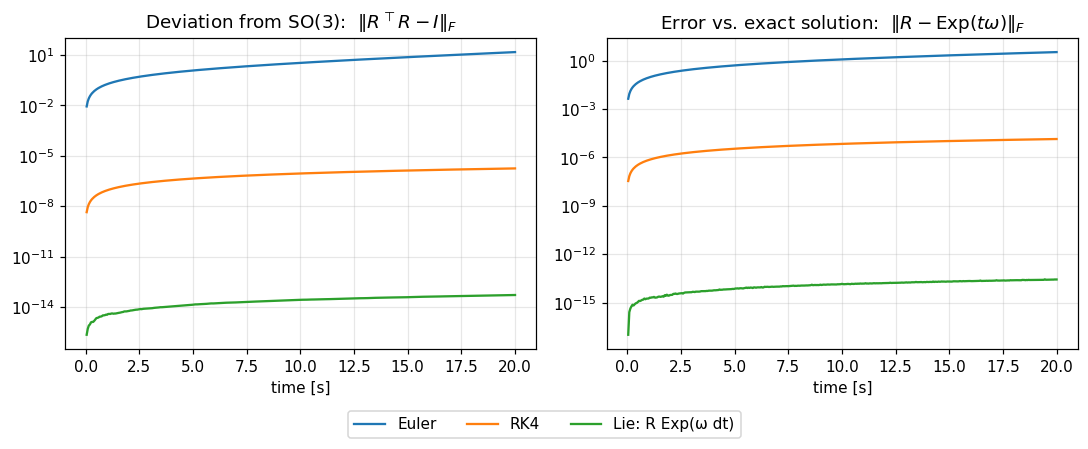

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for name in steps:
    axes[0].semilogy(t_grid, np.maximum(orth_err[name], 1e-17), label=name)
    axes[1].semilogy(t_grid, np.maximum(exact_err[name], 1e-17), label=name)

axes[0].set(title=r"Deviation from SO(3):  $\|R^\top R - I\|_F$", xlabel="time [s]")
axes[1].set(title=r"Error vs. exact solution:  $\|R - \mathrm{Exp}(t\omega)\|_F$", xlabel="time [s]")
handles, names = axes[0].get_legend_handles_labels()
fig.legend(handles, names, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.show()

- **オイラー法**：更新のたびに行列が膨らみ、数秒で SO(3) から大きく外れます。もはや回転行列とは呼べません。
- **RK4**：オイラー法よりはるかに良いものの、ずれは時間とともに蓄積していきます。
- **Lie群積分**：ずれは丸め誤差程度（$10^{-14}$ 前後）のままで、一定角速度の厳密解 $\mathrm{Exp}(t\omega)$ とも一致します。

角速度が時間とともに変化する場合、この Lie群積分は一般に1次精度ですが、$R_k$ が常に SO(3) 上にある点は変わりません。精度を上げたいときは、同じ考え方に基づく高次の Lie群積分法（Runge–Kutta–Munthe-Kaas 法など）があります。

## 6. SE(2)・SE(3)：位置と姿勢をまとめて扱う

ロボットの「位置と向き」は、回転 $R$ と並進 $p$ を1つの行列にまとめた**同次変換行列**で表せます。平面の場合は次のとおりです。

$$
T = \begin{pmatrix} R & p \\ 0 & 1 \end{pmatrix} \in \mathrm{SE}(2) \subset \mathbb{R}^{3\times 3}, \qquad R \in \mathrm{SO}(2),\ p \in \mathbb{R}^2
$$

行列の掛け算 $T_1 T_2$ が「座標変換の合成」になるのが便利な点です（SE(3) なら $4\times 4$ 行列になります）。

In [20]:
# 世界座標系でのロボットの姿勢 T_wr：位置 (2, 1)、向き 90°
T_wr = np.eye(3)
T_wr[:2, :2] = R2(np.pi / 2).full()
T_wr[:2, 2] = [2.0, 1.0]

p_r = np.array([1.0, 0.0, 1.0])        # ロボット座標系で「1 m 前方」の点（同次座標）
print("世界座標系での位置:", (T_wr @ p_r)[:2])

世界座標系での位置: [2. 2.]


### Lie代数と指数写像

SE(2) のLie代数の元は、並進の速度 $\rho \in \mathbb{R}^2$ と回転の速度 $\omega \in \mathbb{R}$ を並べた $\xi = (\rho, \omega)$ です。

$$
\xi^\wedge = \begin{pmatrix} \omega^\wedge & \rho \\ 0 & 0 \end{pmatrix}, \quad \omega^\wedge = \begin{pmatrix} 0 & -\omega \\ \omega & 0 \end{pmatrix}
$$

指数写像は次のように書けます。

$$
\mathrm{Exp}(\xi) = \exp(\xi^\wedge) = \begin{pmatrix} R(\omega) & V(\omega)\,\rho \\ 0 & 1 \end{pmatrix}, \qquad
V(\omega) = \frac{\sin\omega}{\omega}\,I + \frac{1-\cos\omega}{\omega} \begin{pmatrix} 0 & -1 \\ 1 & 0 \end{pmatrix}
$$

$\mathrm{Exp}(\xi)$ は、「ボディ座標系で一定の速度 $\xi$ のまま1秒間動いたときの姿勢の変化」を表します。これは**円弧**に沿った移動です（$\omega \to 0$ では $V \to I$ となり、直進になります）。$\mathrm{Log}$ は $\omega = \mathrm{atan2}(R_{21}, R_{11})$、$\rho = V(\omega)^{-1} p$ で求められます。

In [21]:
def exp_se2(xi):
    """Exp: R^3 -> SE(2)。xi = (ρx, ρy, ω)"""
    rho, w = xi[:2], xi[2]
    A, B, _ = trig_coeffs(w**2)
    R = ca.vertcat(ca.horzcat(ca.cos(w), -ca.sin(w)),
                   ca.horzcat(ca.sin(w),  ca.cos(w)))
    V = ca.vertcat(ca.horzcat(A, -w * B),
                   ca.horzcat(w * B,  A))                  # V = (sin w / w) I + ((1 - cos w) / w) [[0,-1],[1,0]]
    return ca.vertcat(ca.horzcat(R, V @ rho), ca.horzcat(0, 0, 1))

def log_se2(T):
    """Log: SE(2) -> R^3"""
    R, p = T[:2, :2], T[:2, 2]
    w = ca.atan2(R[1, 0], R[0, 0])
    A, B, _ = trig_coeffs(w**2)
    V = ca.vertcat(ca.horzcat(A, -w * B),
                   ca.horzcat(w * B,  A))
    return ca.vertcat(ca.solve(V, p), w)

xi_s, T_s = ca.SX.sym("xi_s", 3), ca.SX.sym("T_s", 3, 3)
Exp_SE2 = ca.Function("Exp_SE2", [xi_s], [exp_se2(xi_s)])
Log_SE2 = ca.Function("Log_SE2", [T_s],  [log_se2(T_s)])

xi0 = np.array([1.0, 0.5, 0.8])
T0 = Exp_SE2(xi0).full()
xi0_hat = np.array([[0, -xi0[2], xi0[0]],
                    [xi0[2], 0,  xi0[1]],
                    [0,      0,  0     ]])
print("expm（級数）と一致 :", np.allclose(T0, expm_series(xi0_hat)))
print("Log(Exp(ξ)) = ξ   :", np.allclose(Log_SE2(T0).full().ravel(), xi0))

expm（級数）と一致 : True
Log(Exp(ξ)) = ξ   : True


### 例：移動ロボットの走行

ボディ座標系で前進速度 $v$・旋回速度 $\omega$ が一定なら、ロボットは円を描きます。この運動は

$$
T_{k+1} = T_k\,\mathrm{Exp}\bigl(\Delta t\,(v, 0, \omega)\bigr)
$$

で、**時間刻み $\Delta t$ によらず厳密に**表せます。座標 $(x, y, \theta)$ をそのままオイラー法で更新する方法と比べてみましょう。

厳密解との最大誤差（位置）
  Lie群 : 7.0e-16
  Euler : 5.3e-01


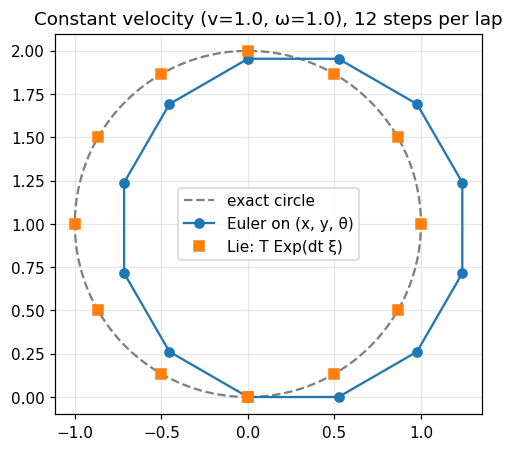

In [22]:
v, w = 1.0, 1.0                           # 前進速度 [m/s]、旋回速度 [rad/s]  ->  半径 v/w = 1 m の円
n = 12
dt = 2 * np.pi / (w * n)                  # 1周を 12 ステップで走る（かなり粗い時間刻み）

# (a) Lie群：T <- T Exp(dt ξ)
T_k = np.eye(3)
path_lie = [T_k[:2, 2]]
for _ in range(n):
    T_k = T_k @ Exp_SE2([v * dt, 0.0, w * dt]).full()
    path_lie.append(T_k[:2, 2])

# (b) (x, y, θ) をそのままオイラー法で更新
x, y, yaw = 0.0, 0.0, 0.0
path_euler = [(x, y)]
for _ in range(n):
    x, y, yaw = x + v * np.cos(yaw) * dt, y + v * np.sin(yaw) * dt, yaw + w * dt
    path_euler.append((x, y))

path_lie, path_euler = np.array(path_lie), np.array(path_euler)

# 厳密解：半径 v/w の円周上を角速度 w で進む
t_k = dt * np.arange(n + 1)
exact = (v / w) * np.c_[np.sin(w * t_k), 1 - np.cos(w * t_k)]
print("厳密解との最大誤差（位置）")
print(f"  Lie群 : {np.linalg.norm(path_lie - exact, axis=1).max():.1e}")
print(f"  Euler : {np.linalg.norm(path_euler - exact, axis=1).max():.1e}")

t = np.linspace(0, 2 * np.pi, 200)
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot((v / w) * np.sin(t), (v / w) * (1 - np.cos(t)), "--", color="gray", label="exact circle")
ax.plot(*path_euler.T, "o-", label="Euler on (x, y, θ)")
ax.plot(*path_lie.T, "s", ms=7, label="Lie: T Exp(dt ξ)")
ax.set(aspect="equal", title=f"Constant velocity (v={v}, ω={w}), {n} steps per lap")
ax.legend(loc="center")
plt.show()

Lie群を使った更新は、1周を 12 ステップという粗い時間刻みでも、各ステップの位置が**厳密な円周上にぴったり**乗ります（上の誤差は丸め誤差程度です）。一方、オイラー法は各ステップで「いまの向きにまっすぐ進む」ため円周からずれ、そのずれは時間刻み $\Delta t$ に比例して大きくなります。

### SE(3)

3次元でも構造はまったく同じです。$\xi = (\rho, \phi) \in \mathbb{R}^6$、$T \in \mathbb{R}^{4\times 4}$ として、

$$
\mathrm{Exp}(\xi) = \begin{pmatrix} \mathrm{Exp}(\phi) & V(\phi)\,\rho \\ 0 & 1 \end{pmatrix}, \qquad
V(\phi) = I + \frac{1-\cos\theta}{\theta^2}\,\phi^\wedge + \frac{\theta - \sin\theta}{\theta^3}\,(\phi^\wedge)^2
$$

です。$V(\phi)$ は**左ヤコビアン** $J_l(\phi) = J_r(-\phi)$ に一致します。$\mathrm{Log}$ は、$\phi = \mathrm{Log}(R)$、$\rho = V(\phi)^{-1} p$ で求められます。SO(3) 用に作った関数をそのまま再利用できます。

In [23]:
def exp_se3(xi):
    """Exp: R^6 -> SE(3)。xi = (ρ, φ)"""
    rho, ph = xi[:3], xi[3:]
    A, B, C = trig_coeffs(ca.dot(ph, ph))
    W = hat(ph)
    R = ca.SX.eye(3) + A * W + B * (W @ W)                 # Exp(φ)
    V = ca.SX.eye(3) + B * W + C * (W @ W)                 # 左ヤコビアン J_l(φ)
    return ca.vertcat(ca.horzcat(R, V @ rho), ca.horzcat(0, 0, 0, 1))

def log_se3(T):
    """Log: SE(3) -> R^6"""
    R, p = T[:3, :3], T[:3, 3]
    ph = log_so3(R)
    _, B, C = trig_coeffs(ca.dot(ph, ph))
    W = hat(ph)
    V = ca.SX.eye(3) + B * W + C * (W @ W)
    return ca.vertcat(ca.solve(V, p), ph)

xi6_s, T4_s = ca.SX.sym("xi6_s", 6), ca.SX.sym("T4_s", 4, 4)
Exp_SE3 = ca.Function("Exp_SE3", [xi6_s], [exp_se3(xi6_s)])
Log_SE3 = ca.Function("Log_SE3", [T4_s],  [log_se3(T4_s)])

xi6 = np.array([0.3, -0.2, 0.5, 0.4, -0.6, 0.9])
T6 = Exp_SE3(xi6).full()
xi6_hat = np.zeros((4, 4))
xi6_hat[:3, :3] = hat(xi6[3:]).full()
xi6_hat[:3, 3] = xi6[:3]
print("expm（級数）と一致 :", np.allclose(T6, expm_series(xi6_hat)))
print("Log(Exp(ξ)) = ξ   :", np.allclose(Log_SE3(T6).full().ravel(), xi6))

expm（級数）と一致 : True
Log(Exp(ξ)) = ξ   : True


### 例：2つの姿勢の補間

姿勢 $T_0$ から $T_1$ へなめらかに移るには、Lie代数の上で**直線的**に動かして $\mathrm{Exp}$ で戻します。

$$
T(s) = T_0\,\mathrm{Exp}\bigl(s\,\mathrm{Log}(T_0^{-1} T_1)\bigr), \qquad s \in [0, 1]
$$

行列の成分どうしを直接補間する $(1-s)\,T_0 + s\,T_1$ と比べると、後者は SE(3) の元になりません。回転部分の $\det R$ を見てみましょう（回転行列なら常に 1 です）。

In [24]:
T0 = np.eye(4)
T1 = Exp_SE3([1.2, 0.4, 1.4, 0.2, 0.5, 2.2]).full()           # 目標の姿勢（回転は約 130°）
xi_01 = Log_SE3(np.linalg.inv(T0) @ T1).full().ravel()        # T0 から T1 へのずれ（Lie代数の元）

s_list = np.linspace(0, 1, 6)
T_geo = [T0 @ Exp_SE3(s * xi_01).full() for s in s_list]      # Lie代数上での直線補間
T_lin = [(1 - s) * T0 + s * T1 for s in s_list]               # 成分ごとの線形補間

print("   s   det R（Exp/Log 補間）   det R（成分の線形補間）")
for s, Tg, Tl in zip(s_list, T_geo, T_lin):
    print(f"  {s:.1f}        {np.linalg.det(Tg[:3, :3]):.4f}                  {np.linalg.det(Tl[:3, :3]):.4f}")

   s   det R（Exp/Log 補間）   det R（成分の線形補間）
  0.0        1.0000                  1.0000
  0.2        1.0000                  0.4753
  0.4        1.0000                  0.2129
  0.6        1.0000                  0.2129
  0.8        1.0000                  0.4753
  1.0        1.0000                  1.0000


図にすると違いが一目で分かります。左は Exp/Log による補間、右は成分ごとの線形補間です。右の途中の座標系は軸が縮み、直交でもなくなっています（剛体の姿勢ではありません）。

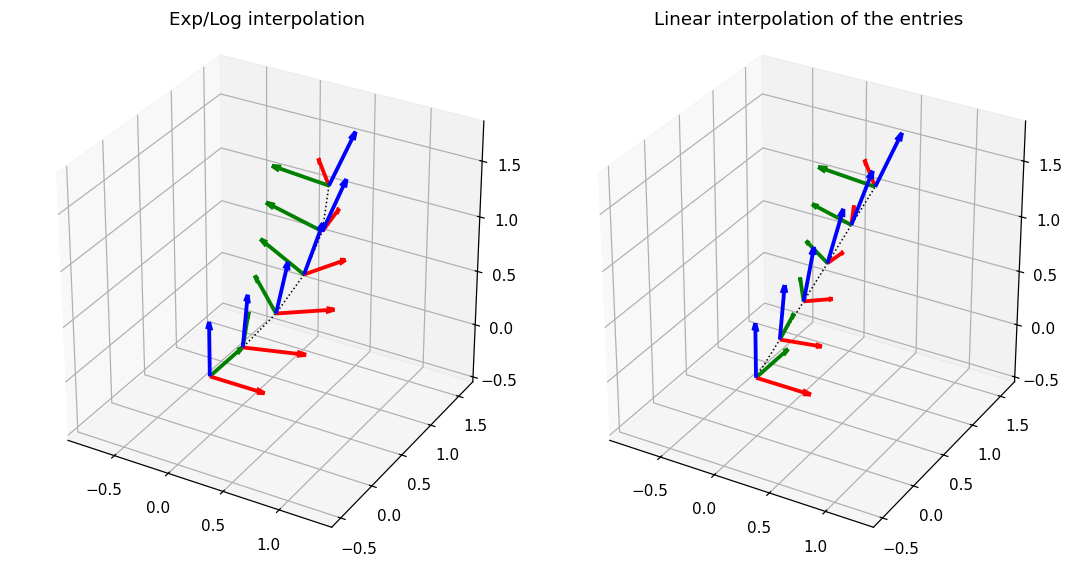

In [25]:
fig = plt.figure(figsize=(10, 5))
for k, (Ts, title) in enumerate([(T_geo, "Exp/Log interpolation"), (T_lin, "Linear interpolation of the entries")]):
    ax = fig.add_subplot(1, 2, k + 1, projection="3d")
    for T in Ts:
        draw_frame(ax, T[:3, :3], p=T[:3, 3], scale=0.5)
    pts = np.array([T[:3, 3] for T in Ts])
    ax.plot(*pts.T, "k:", lw=1)
    setup_3d(ax, lim=1.2, center=(pts.max(0) + pts.min(0)) / 2, title=title)
plt.tight_layout()
plt.show()

## 7. Lie群上の最適化

最後に、ここまでに作った $\mathrm{Exp}$・$\mathrm{Log}$ と自動微分を組み合わせて、Lie群の上の最適化問題を解いてみましょう。

Lie群の元 $X$（回転や姿勢）を変数とする最適化では、$X$ を足し算で動かすのではなく、**Lie代数の元 $\delta$ を使って $X \leftarrow X\,\mathrm{Exp}(\delta)$ と更新**します。$\delta$ はふつうのベクトルなので、微分も線形化も、制約なしの最適化と同じように扱えます。以下の2つの例は、どちらもこの考え方に基づいています。

### 7.1 回転の推定（Gauss–Newton法）

3次元の点 $p_i$ を未知の回転 $R$ で回した点 $q_i = R\,p_i + (\text{ノイズ})$ が観測されたとき、$R$ を推定する問題です（姿勢推定や点群の位置合わせで現れる、いわゆる Wahba の問題です）。

$$
\min_{R \in \mathrm{SO}(3)} \ \sum_{i=1}^{N} \lVert R\,p_i - q_i \rVert^2
$$

$R$ の9成分に $R^\top R = I$ という制約をつけて解く代わりに、**現在の推定値 $R_k$ のまわりで $R = R_k\,\mathrm{Exp}(\delta)$ と置き、制約のない3変数 $\delta$ の問題として解きます**。

1. 残差 $r(\delta) = \bigl( R_k\,\mathrm{Exp}(\delta)\,p_i - q_i \bigr)_{i=1,\dots,N}$ を $\delta = 0$ のまわりで線形化する：$r(\delta) \approx r_0 + J\,\delta$（$J$ は CasADi の自動微分で得る）
2. 線形最小二乗の解 $\delta^\star = -(J^\top J)^{-1} J^\top r_0$ を求める
3. **群の掛け算で更新**する：$R_{k+1} = R_k\,\mathrm{Exp}(\delta^\star)$

更新が足し算ではなく掛け算なので、$R_k$ は常に SO(3) 上にあります。

In [26]:
rng = np.random.default_rng(0)
N = 20
R_true = Exp_SO3([0.8, -0.5, 1.2]).full()                  # 真の回転（約 87°）
P = rng.normal(size=(3, N))                                # 点 p_i（3×N 行列）
Q = R_true @ P + 0.05 * rng.normal(size=(3, N))            # 観測 q_i = R p_i + ノイズ

delta = ca.SX.sym("delta", 3)
R_k_s = ca.SX.sym("R_k_s", 3, 3)
res = ca.vec(R_k_s @ Exp_SO3(delta) @ P - Q)               # 残差 r(δ)（3N 次元のベクトル）
gauss_newton = ca.Function("gauss_newton", [R_k_s, delta], [res, ca.jacobian(res, delta)])

R_est = np.eye(3)                                          # 初期値：単位行列
for it in range(20):
    r, J = gauss_newton(R_est, np.zeros(3))                # δ = 0 での残差とヤコビ行列
    r, J = r.full().ravel(), J.full()
    delta_star = -np.linalg.solve(J.T @ J, J.T @ r)        # 3変数の線形最小二乗
    print(f"iter {it}:  cost = {r @ r:9.5f},  |δ*| = {np.linalg.norm(delta_star):.2e}")
    R_est = R_est @ Exp_SO3(delta_star).full()             # 群の掛け算で更新
    if np.linalg.norm(delta_star) < 1e-10:                 # 更新量が十分小さくなったら終了
        break

iter 0:  cost =  51.32329,  |δ*| = 1.01e+00
iter 1:  cost =   7.25430,  |δ*| = 5.12e-01
iter 2:  cost =   0.16204,  |δ*| = 2.33e-02
iter 3:  cost =   0.14720,  |δ*| = 3.47e-04
iter 4:  cost =   0.14720,  |δ*| = 5.02e-06
iter 5:  cost =   0.14720,  |δ*| = 7.40e-08
iter 6:  cost =   0.14720,  |δ*| = 1.09e-09
iter 7:  cost =   0.14720,  |δ*| = 1.60e-11


数回の反復でコストが収束しました。結果を、閉じた解（SVD を使う Kabsch 法）と比べて確認します。2つの回転の差は、$\mathrm{Log}(R_a^\top R_b)$ のノルム（回転角）で測れます。

In [27]:
# 閉じた解（Kabsch 法）：P Q^T の特異値分解から求める
U_svd, _, Vt_svd = np.linalg.svd(P @ Q.T)
D_svd = np.diag([1.0, 1.0, np.sign(np.linalg.det(Vt_svd.T @ U_svd.T))])   # det = +1 にする補正
R_svd = Vt_svd.T @ D_svd @ U_svd.T

angle = lambda Ra, Rb: np.linalg.norm(Log_SO3(Ra.T @ Rb).full())    # 2つの回転の差 [rad]
print("R^T R = I            :", np.allclose(R_est.T @ R_est, np.eye(3)))
print("GN と Kabsch 法の差   :", angle(R_est, R_svd), "[rad]")
print("GN と真の回転の差     :", angle(R_est, R_true), "[rad]  （観測ノイズによる誤差）")

R^T R = I            : True
GN と Kabsch 法の差   : 2.3261974528301445e-13 [rad]
GN と真の回転の差     : 0.01401445987891809 [rad]  （観測ノイズによる誤差）


### 7.2 SE(2) 上の軌道最適化（`Opti`）

CasADi の最適化インターフェース `Opti` と組み合わせて、**目標の姿勢（位置と向き）にちょうど到達する、入力エネルギー最小の軌道**を求めます。

- 状態は $T_k \in \mathrm{SE}(2)$、入力は前進速度 $v_k$ と旋回速度 $\omega_k$
- 動力学：$T_{k+1} = T_k\,\mathrm{Exp}\bigl(\Delta t\,(v_k, 0, \omega_k)\bigr)$（先ほどの円弧運動を1ステップずつつなぐ）
- 終端条件：$\mathrm{Log}(T_{\mathrm{goal}}^{-1}\,T_N) = 0$

終端条件の $\mathrm{Log}(T_{\mathrm{goal}}^{-1}\,T_N)$ は、目標との**姿勢の誤差を Lie代数の3次元ベクトルで表したもの**です。これが 0 のとき $T_N = T_{\mathrm{goal}}$ になります。向きの誤差も自動的に $(-\pi, \pi]$ の最短の角度差として扱われるので、角度の巻き戻しを気にしなくて済みます。

In [28]:
N, dt = 30, 0.2                                      # 6 秒間を 30 ステップに分割
T_goal = np.eye(3)
T_goal[:2, :2] = R2(np.pi / 2).full()
T_goal[:2, 2] = [3.0, 2.0]                           # 目標：位置 (3, 2)、向き 90°

opti = ca.Opti()
U = opti.variable(2, N)                              # 入力 (v_k, ω_k)

T_k = ca.DM.eye(3)                                   # 初期姿勢：原点、向き 0
for k in range(N):
    xi_k = ca.vertcat(U[0, k], 0, U[1, k])           # ボディ座標系の速度 (v, 0, ω)
    T_k = T_k @ Exp_SE2(dt * xi_k)                   # T_{k+1} = T_k Exp(dt ξ_k)

opti.subject_to(Log_SE2(ca.DM(np.linalg.inv(T_goal)) @ T_k) == 0)   # 終端条件：目標姿勢に一致
opti.subject_to(opti.bounded(0.0, U[0, :], 1.0))                    # 0 <= v <= 1
opti.subject_to(opti.bounded(-1.0, U[1, :], 1.0))                   # |ω| <= 1
opti.minimize(dt * ca.sumsqr(U))                                    # 入力エネルギーを最小化
opti.set_initial(U, ca.repmat(ca.DM([0.5, 0.0]), 1, N))             # 初期値：まっすぐ進む

opti.solver("ipopt", {"print_time": False}, {"print_level": 0, "sb": "yes"})
sol = opti.solve()
U_opt = sol.value(U)
print("終了ステータス:", sol.stats()["return_status"], "／ コスト:", round(float(sol.value(opti.f)), 4))

終了ステータス: Solve_Succeeded ／ コスト: 3.0161


終端誤差 ‖Log(T_goal^-1 T_N)‖ = 5.802527125277759e-11


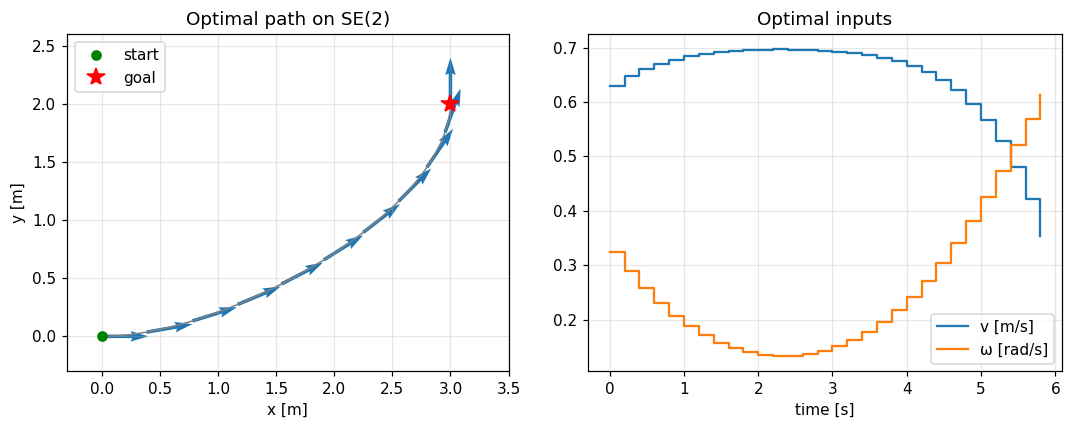

In [29]:
# 得られた入力で Exp を使ってロボットを走らせ、軌道を確認する
T_k = np.eye(3)
path = [T_k]
for k in range(N):
    T_k = T_k @ Exp_SE2(dt * np.array([U_opt[0, k], 0.0, U_opt[1, k]])).full()
    path.append(T_k)
path = np.array(path)

print("終端誤差 ‖Log(T_goal^-1 T_N)‖ =", np.linalg.norm(Log_SE2(np.linalg.inv(T_goal) @ path[-1]).full()))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ax = axes[0]
idx = np.arange(0, N + 1, 3)                                                 # 3 ステップおきに姿勢（向き）を矢印で表示
ax.plot(path[:, 0, 2], path[:, 1, 2], "-", color="gray", lw=1)
ax.quiver(path[idx, 0, 2], path[idx, 1, 2], path[idx, 0, 0], path[idx, 1, 0],
          angles="xy", scale_units="xy", scale=2.5, width=0.008, color="C0")   # 矢印の長さ 0.4 m
ax.plot(0, 0, "go", label="start")
ax.plot(3, 2, "r*", ms=12, label="goal")
ax.set(aspect="equal", xlim=(-0.3, 3.5), ylim=(-0.3, 2.6), xlabel="x [m]", ylabel="y [m]", title="Optimal path on SE(2)")
ax.legend(loc="upper left")

t_u = dt * np.arange(N)
axes[1].step(t_u, U_opt[0], where="post", label="v [m/s]")
axes[1].step(t_u, U_opt[1], where="post", label="ω [rad/s]")
axes[1].set(xlabel="time [s]", title="Optimal inputs")
axes[1].legend()
plt.tight_layout()
plt.show()

軌道は、スタートの向き（0°）から目標の向き（90°）へなめらかに旋回しながら、目標位置に正確に到達しています。入力の制約（$0 \le v \le 1$、$|\omega| \le 1$）も満たしています。

なお、これは非凸な最適化問題なので、初期値によっては別の局所解に収束することがあります。

## まとめ

| 概念 | 数式 | このノートブックでの実装 |
| --- | --- | --- |
| hat / vee | $\phi^\wedge$, $(\cdot)^\vee$ | `hat`, `vee` |
| 指数写像 | $\mathrm{Exp}(\phi)$ | `Exp_SO3`, `Exp_SE2`, `Exp_SE3` |
| 対数写像 | $\mathrm{Log}(R)$ | `Log_SO3`, `Log_SE2`, `Log_SE3` |
| 群上の微分 | $\partial f(R\,\mathrm{Exp}(\delta)) / \partial\delta$ | `ca.jacobian` |
| 群上の更新 | $R \leftarrow R\,\mathrm{Exp}(\delta)$ | Lie群積分、Gauss–Newton法 |
| 誤差の測り方 | $\mathrm{Log}(T_{\mathrm{goal}}^{-1}\,T)$ | `Log_SE2`（`Opti` の終端条件） |

ポイントを振り返ります。

- Lie群は「掛け算のできる曲がった空間」、Lie代数はその単位元における「平らな接空間」です。両者は $\mathrm{Exp}$ と $\mathrm{Log}$ で行き来します。
- 回転は足し算ではなく**掛け算**で合成します。Lie括弧は、その非可換性（順序による違い）を表します。
- 微分・更新・誤差は **Lie代数（ベクトル）の側**で扱い、群の元に戻すときに $\mathrm{Exp}$ を使います。すると、制約つきの問題が**制約なしの問題**として解けます。
- CasADi の自動微分を使えば、$\mathrm{Exp}$・$\mathrm{Log}$ を合成した関数のヤコビ行列も、手計算なしで正確に求められます。

### 発展的な話題

- 左摂動と随伴表現 $\mathrm{Ad}_T$（座標系を変えたときのツイストの変換）
- ロボットアームの順運動学（指数積公式）とヤコビ行列の自動微分
- SO(3) 上のモデル予測制御（ドローンの姿勢制御など）
- SE(2)/SE(3) 上のポーズグラフ最適化（SLAM）

### 参考文献・リンク

- J. Solà, J. Deray, D. Atchuthan, [A micro Lie theory for state estimation in robotics](https://arxiv.org/abs/1812.01537), arXiv:1812.01537, 2018.（本ノートブックの記法の多くはこの文献に倣っています）
- T. D. Barfoot, *State Estimation for Robotics*, Cambridge University Press, 2017.
- K. M. Lynch, F. C. Park, *Modern Robotics: Mechanics, Planning, and Control*, Cambridge University Press, 2017.
- B. C. Hall, *Lie Groups, Lie Algebras, and Representations: An Elementary Introduction*, 2nd ed., Springer, 2015.
- J. A. E. Andersson, J. Gillis, G. Horn, J. B. Rawlings, M. Diehl, *CasADi: a software framework for nonlinear optimization and optimal control*, Mathematical Programming Computation, 11(1), 1–36, 2019.
- [CasADi 公式サイト](https://web.casadi.org/)
- 深津卓弥・菱沼徹・荒牧大輔『[PythonとCasADiで学ぶモデル予測制御](https://www.kspub.co.jp/book/detail/5356111.html)』講談社サイエンティフィク, 2024.（モデル予測制御を CasADi の Python サンプルコードとともに解説した書籍です）